In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
merge_df=pd.read_csv(r"D:\Vanshika_reja\Need\CSV_files\merged_trader_sentiment.csv")
df= merge_df.copy()
df

,Account,trade_date,total_daily_pnl,num_trades,wins,avg_size_used,avg_fee,win_rate,value,sentiment_class
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0,5089.718249,0.948000,0.000000,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,0,7976.664412,0.998288,0.000000,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,0,23734.500000,2.373450,0.000000,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,0,28186.666667,2.818666,0.000000,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,12,17248.148148,3.874907,0.444444,79.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,82,32,2153.859390,0.312681,0.390244,61.0,Greed
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,430,169,1495.538419,0.371047,0.393023,54.0,Neutral
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,902,398,1939.739989,0.386831,0.441242,60.0,Greed
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,75,39,1748.805333,0.270870,0.520000,56.0,Greed


### Sentiment vs Performance Analysis

In [10]:
sent_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

def plot_sent_vs_prf(data, X="sentiment_class", y="total_daily_pnl"):
  plt.figure(figsize=(8, 4))
  sns.barplot(
    data=data,
    x=X, y=y, order=sent_order, estimator="mean", errorbar="ci"
  )
  plt.xticks(rotation=30)
  plt.ylabel(f"{y}")
  plt.xlabel(f"{X}")
  plt.title(f"{X} vs {y} Analysis")
  plt.tight_layout()
  plt.show()

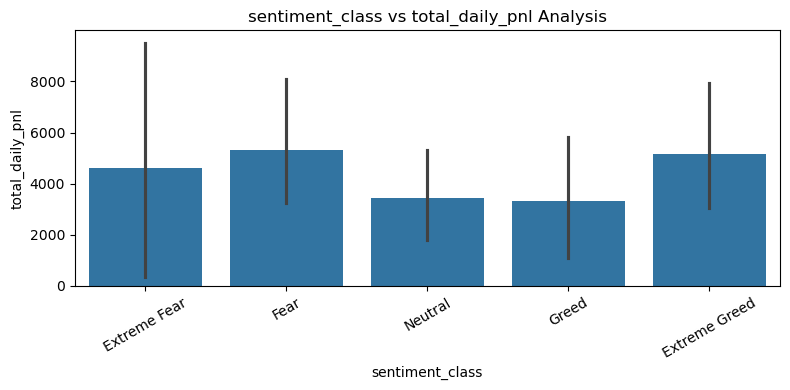

In [11]:
plot_sent_vs_prf(df, "sentiment_class", "total_daily_pnl" )

* Fear and extereme greed days have highest daily PnL (arround 5000)
* Extereme Fear days are slighly lower but still strong PnL
* Neutral and greed days shows the lowest average PnL(arround 3300-3500)
* There is hight variability in PnL on all sentiment days (some account make a lot, some lose a lot).
* Especially on Extreme Fear and Fear days there is shown some very profitable and some very unfrofitable outcomes within the same sentiment bucket.

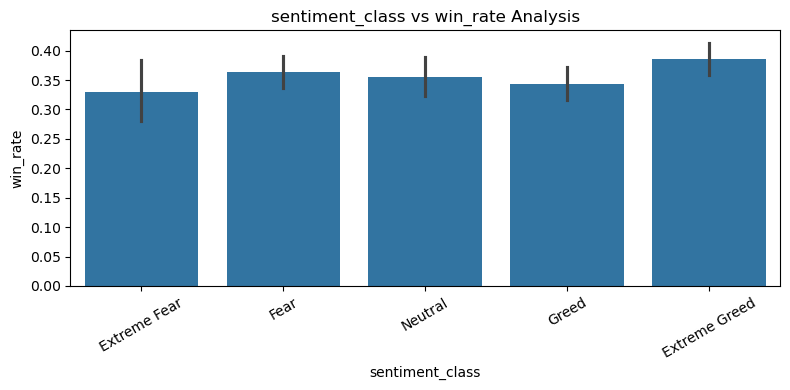

In [12]:
plot_sent_vs_prf(df, "sentiment_class", "win_rate" )

* Extreme Greed regimes show both high win_rate and high average PnL, indicating broadly favourable trading conditions or trend‑following opportunities.
* Extreme Fear regimes show low win_rate but strong PnL, suggesting that although most trades lose, a minority of trades capture large moves or that risk is managed tightly.
* Moderate Greed days are the weakest: both average PnL and win_rate are relatively low, hinting at overconfidence and overtrading without clear edge.
* There is a high variability in the Extreme Fear block means
somewhere the win rate was extremely low and somewhere high.

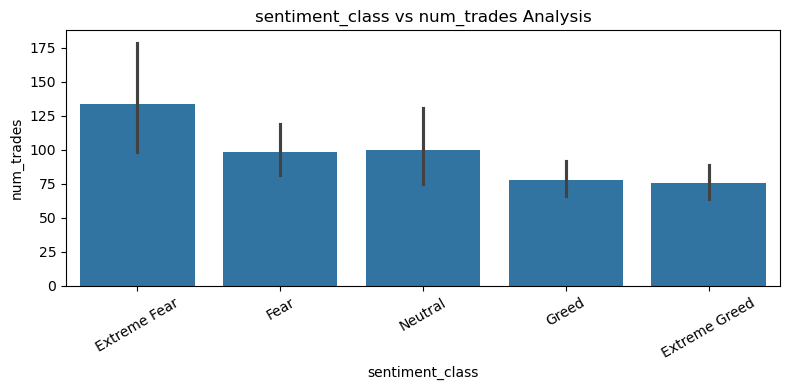

In [13]:
plot_sent_vs_prf(df, "sentiment_class", "num_trades" )

* This chart shows the average number of trades per account-day for each sentiment class.
* On Extreme Fear days, traders execute the highest number of trades (~130 per account–day), while on Greed and Extreme Greed days activity is lower (~75 trades per account–day)..
* This suggests that traders trade much more frequently on Extreme Fear days, which likely contributes to the high variability in win rates and PnL observed on those days. In contrast, Extreme Greed days combine fewer trades with higher win rates and PnL, indicating that traders may be more selective but more effective in optimistic markets.
* Fear and Neutral sentiment days sit in the middle, with around 100 trades per account–day and moderate variability.

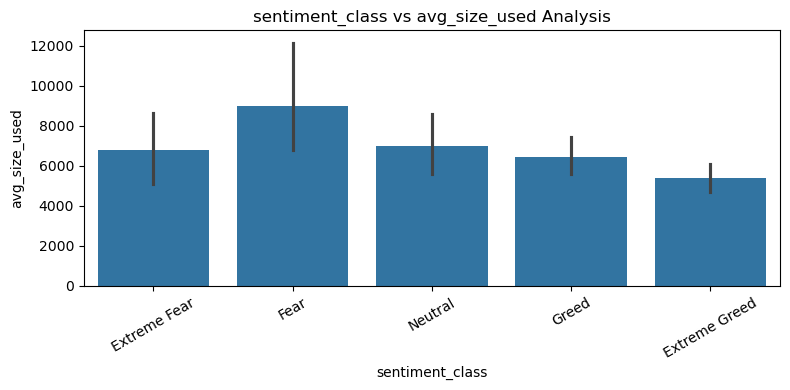

In [14]:
plot_sent_vs_prf(df, "sentiment_class", "avg_size_used" )

* The chart shows the average size in USD of trade per account or per day for each sentiment class
* On Fear days the average size is 9000 USD which is higher from all the other class. we can also observe that Extreme Greed class have average of 5800 which is lowest means the class who is almost winning have played safely, nither too long nor too short.
* The combination of high average size on Fear days with only moderate win rates suggests that traders take larger positions when the market is fearful, potentially trying to exploit perceived discounts, but this also increases risk.
* In contrast, Extreme Greed days appear to be traded more cautiously in terms of position size (smaller average trades) while still delivering high win rates and PnL, indicating that traders may rely on strong trends rather than oversized bets.
* As in earlier charts, Extreme Fear and Fear also show relatively wide error bars, meaning some accounts trade with very large sizes while others remain conservative, which contributes to the high variability in outcomes on those days.

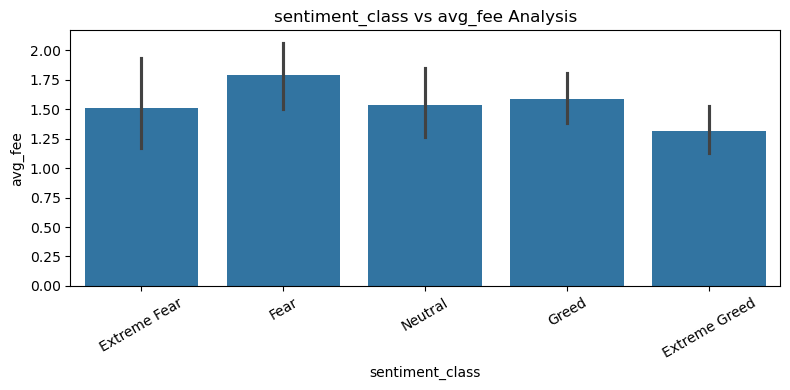

In [15]:
plot_sent_vs_prf(df, "sentiment_class", "avg_fee")

* The chart shows the average trading fee in USD per account–day for each sentiment class.
* The pattern closely mirrors the average trade size chart: Fear days have the highest average fee, consistent with their larger average position sizes, while Extreme Greed days have the lowest average fee, in line with their smaller average trade sizes.
* The variability across sentiment classes is also similar to the average size analysis, suggesting that differences in fees are mainly driven by differences in position size, not by big changes in fee rates themselves. 

### Fear/Greed score vs metrics

In [9]:
cols = ["value", "total_daily_pnl", "win_rate", "num_trades", "avg_size_used"]
corr = df[cols].corr()
print(corr)

                    value  total_daily_pnl  win_rate  num_trades  \
value            1.000000         0.000179  0.026899   -0.065340   
total_daily_pnl  0.000179         1.000000  0.210890    0.175620   
win_rate         0.026899         0.210890  1.000000    0.062844   
num_trades      -0.065340         0.175620  0.062844    1.000000   
avg_size_used   -0.057299         0.028496  0.031887   -0.026364   

                 avg_size_used  
value                -0.057299  
total_daily_pnl       0.028496  
win_rate              0.031887  
num_trades           -0.026364  
avg_size_used         1.000000  


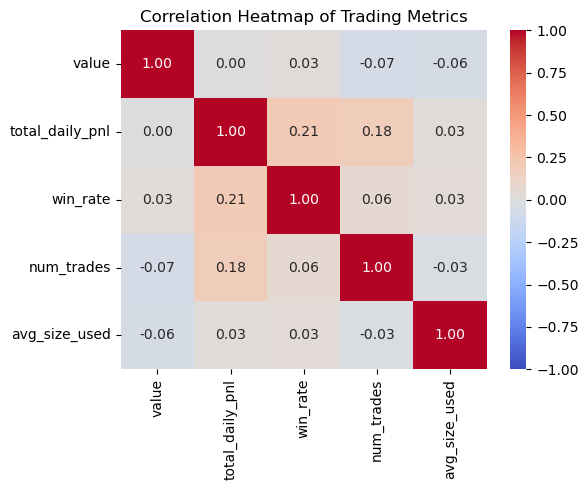

In [64]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,          # show numbers
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap of Trading Metrics")
plt.tight_layout()
plt.show()

* The above columns are not closely realted with each other that no single numeric feature strongly explains trader performance; instead, outcomes appear to result from the combined effect of multiple factors. 

In [16]:
def neumeric_plot(data, X, Y):
  plt.figure(figsize=(6,4))
  sns.scatterplot(
    data=data,
    x=X, y=Y, alpha=0.4
  )

  sns.regplot(
    data=data,
    x=X, y=Y, scatter=False, color="red"
  )
  plt.xlabel("Fear & Greed Index (0 = Fear, 100 = Greed)")
  plt.ylabel(f"{Y}")
  plt.title(f"Relationship Between {X} and {Y}")
  plt.tight_layout()
  plt.show()

In [18]:
merge_df.head()

,Account,trade_date,total_daily_pnl,num_trades,wins,avg_size_used,avg_fee,win_rate,value,sentiment_class
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0,5089.718249,0.948000,0.000000,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0,7976.664412,0.998288,0.000000,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0,23734.500000,2.373450,0.000000,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,0,28186.666667,2.818666,0.000000,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,12,17248.148148,3.874907,0.444444,79.0,Extreme Greed


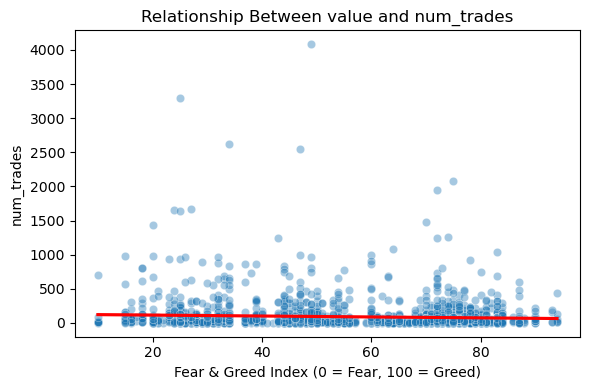

In [ ]:
neumeric_plot(df, "value", "num_trades")

* The scatter plot of Fear & Greed Index versus number of trades shows a flat regression line and a wide dispersion of points, indicating no strong linear relationship. Traders do not systematically increase or decrease their trading frequency as market sentiment moves from fear to greed.

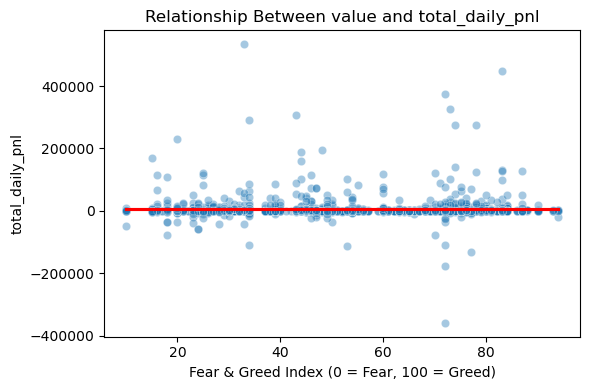

In [ ]:
neumeric_plot(df, "value", "total_daily_pnl")

* Th epoints are widely scattred above and below Zero PnL and the regression line is also flat.
* This means changes in the Fear & Greed Index do not systematically increase or decrease daily PnL at the account level.

### Per Account Analysis 

In [22]:
numeric_cols = df.select_dtypes(include="number").columns
df_acc_sent = (
    df.groupby(["Account", "sentiment_class"])[numeric_cols]
      .mean()
      .reset_index()
)

In [23]:
df_acc_sent

,Account,sentiment_class,total_daily_pnl,num_trades,wins,avg_size_used,avg_fee,win_rate,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,62384.610721,50.000000,18.500000,13972.353051,1.322590,0.409091,18.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-4475.815100,105.000000,7.000000,18629.717948,3.529325,0.115881,81.777778
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,222674.709503,355.600000,187.200000,19744.414635,1.582597,0.581110,37.600000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,92239.756729,191.333333,30.666667,77720.016527,4.764054,0.352103,68.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,25130.023348,84.200000,49.000000,55632.832597,4.162026,0.526605,48.200000
...,...,...,...,...,...,...,...,...,...
151,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Fear,2797.644739,461.727273,190.818182,1446.510185,0.331523,0.432713,19.181818
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,20817.889921,292.304348,174.304348,2198.274227,0.195593,0.424967,78.391304
153,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,1301.832487,300.023256,112.976744,1510.971221,0.324147,0.406899,33.627907
154,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,8692.839755,262.071429,121.785714,1958.823555,0.283113,0.376573,67.750000


In [26]:
acc_overall = (
    df_acc_sent.groupby("Account")["total_daily_pnl"].mean().sort_values(ascending=False).reset_index()
)

n = 20
top_accounts = acc_overall["Account"].head(n).tolist()
bottom_accounts = acc_overall["Account"].tail(n).tolist()

def label_group(acc):
    if acc in top_accounts:
        return "Top"
    elif acc in bottom_accounts:
        return "Bottom"
    else:
        return "Middle"

df_acc_sent["Account_group"] = df_acc_sent["Account"].apply(label_group)


In [27]:
df_acc_sent

,Account,sentiment_class,total_daily_pnl,num_trades,wins,avg_size_used,avg_fee,win_rate,value,Account_group
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,62384.610721,50.000000,18.500000,13972.353051,1.322590,0.409091,18.000000,Top
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-4475.815100,105.000000,7.000000,18629.717948,3.529325,0.115881,81.777778,Top
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,222674.709503,355.600000,187.200000,19744.414635,1.582597,0.581110,37.600000,Top
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,92239.756729,191.333333,30.666667,77720.016527,4.764054,0.352103,68.000000,Top
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,25130.023348,84.200000,49.000000,55632.832597,4.162026,0.526605,48.200000,Top
...,...,...,...,...,...,...,...,...,...,...
151,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Fear,2797.644739,461.727273,190.818182,1446.510185,0.331523,0.432713,19.181818,Top
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,20817.889921,292.304348,174.304348,2198.274227,0.195593,0.424967,78.391304,Top
153,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,1301.832487,300.023256,112.976744,1510.971221,0.324147,0.406899,33.627907,Top
154,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,8692.839755,262.071429,121.785714,1958.823555,0.283113,0.376573,67.750000,Top


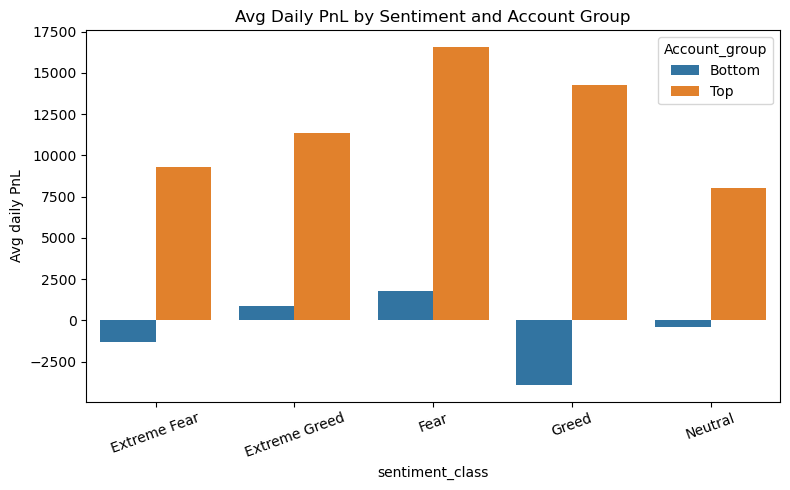

In [28]:
perf_grp = (
    df_acc_sent.groupby(["Account_group", "sentiment_class"])["total_daily_pnl"].mean().reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=perf_grp,
    x="sentiment_class",
    y="total_daily_pnl",
    hue="Account_group"
)
plt.title("Avg Daily PnL by Sentiment and Account Group")
plt.ylabel("Avg daily PnL")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


* The chart compares average daily PnL by sentiment class for the Top and Bottom trader groups.
* Top traders remain strongly profitable across all sentiment regimes, including Extreme Fear and Extreme Greed, while Bottom traders lose money in every sentiment class, even when conditions are optimistic (Greed and Extreme Greed).​
* The gap between Top and Bottom traders is largest on Fear and Greed days, which suggests that market sentiment amplifies the difference in skill or discipline: better traders exploit these regimes, whereas weaker traders tend to overreact and generate larger losses.

In [45]:
fg = df_acc_sent[df_acc_sent["sentiment_class"].isin(["Fear", "Greed"])]

size_pivot = (
    fg.pivot_table(
        index=["Account_group", "Account"],
        columns="sentiment_class",
        values=["avg_size_used", "num_trades"],
        aggfunc="mean"
    )
)
size_pivot.columns = [f"{m}_{s}" for m, s in size_pivot.columns]
size_pivot = size_pivot.reset_index()
size_pivot

,Account_group,Account,avg_size_used_Fear,avg_size_used_Greed,num_trades_Fear,num_trades_Greed
0,Bottom,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,9101.961590,2408.144133,154.235294,196.200000
1,Bottom,0x271b280974205ca63b716753467d5a371de622ab,8905.690333,11878.173588,467.000000,180.000000
2,Bottom,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,551.017149,427.247628,32.534884,80.270270
3,Bottom,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,710.863232,1996.880375,25.600000,11.333333
4,Bottom,0x39cef799f8b69da1995852eea189df24eb5cae3c,75206.878270,12077.192271,122.583333,9.000000
5,Bottom,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,529.851069,483.842241,25.666667,84.950000
6,Bottom,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,4501.825411,6138.028260,108.800000,6.916667
7,Bottom,0x8170715b3b381dffb7062c0298972d4727a0a63b,3173.257000,1250.253373,45.921053,82.650000
8,Bottom,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,2875.925676,9227.501865,9.166667,18.562500
9,Bottom,0x8477e447846c758f5a675856001ea72298fd9cb5,830.641818,749.903639,34.279070,126.000000


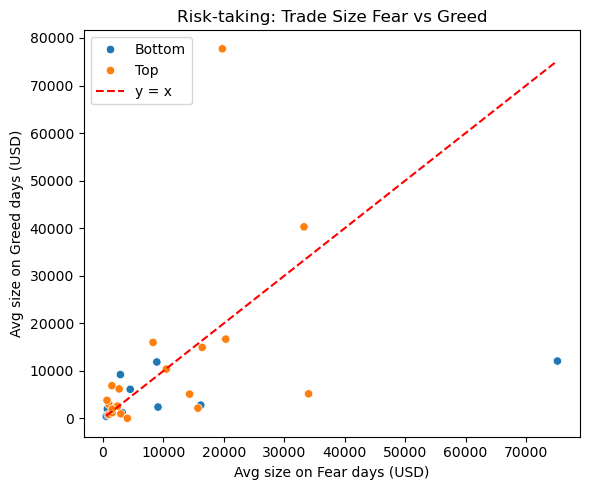

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=size_pivot,
    x="avg_size_used_Fear",
    y="avg_size_used_Greed",
    hue="Account_group"
)
plt.plot(
    [size_pivot["avg_size_used_Fear"].min(), size_pivot["avg_size_used_Fear"].max()],
    [size_pivot["avg_size_used_Fear"].min(), size_pivot["avg_size_used_Fear"].max()],
    "r--", label="y = x"
)
plt.xlabel("Avg size on Fear days (USD)")
plt.ylabel("Avg size on Greed days (USD)")
plt.title("Risk-taking: Trade Size Fear vs Greed")
plt.legend()
plt.tight_layout()
plt.show()


* The scatter plot compares average trade size on Fear days (x‑axis) with average trade size on Greed days (y‑axis) for each account, with the red line representing no change y=x.
* Most Top accounts lie above the red line, meaning they increase their position size on Greed days compared to Fear days, while many Bottom accounts remain closer to the line, indicating relatively stable sizing across sentiments.​
* This suggests that successful traders are willing to scale up their risk when market sentiment is optimistic, whereas weaker traders do not adjust their size as aggressively between Fear and Greed regimes.

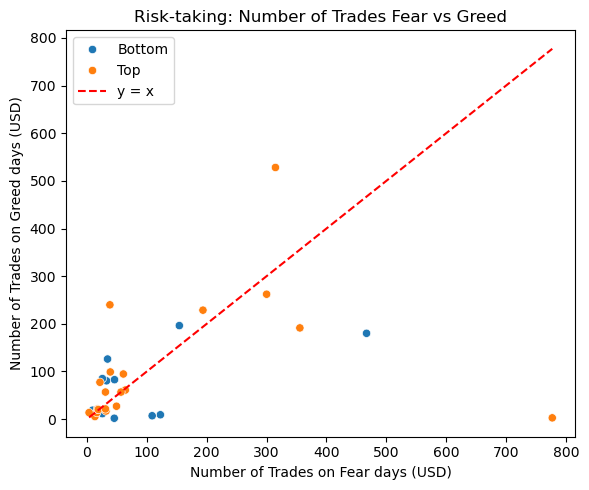

In [63]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=size_pivot,
    x="num_trades_Fear",
    y="num_trades_Greed",
    hue="Account_group"
)
plt.plot(
    [size_pivot["num_trades_Fear"].min(), size_pivot["num_trades_Fear"].max()],
    [size_pivot["num_trades_Fear"].min(), size_pivot["num_trades_Fear"].max()],
    "r--", label="y = x"
)
plt.xlabel("Number of Trades on Fear days (USD)")
plt.ylabel("Number of Trades on Greed days (USD)")
plt.title("Risk-taking: Number of Trades Fear vs Greed")
plt.legend()
plt.tight_layout()
plt.show()

* The scatter plot compares average number of trades on Fear days (x‑axis) with average number of trade on Greed days (y‑axis) for each account, with the red line representing no change y=x.
* Many Top accounts appear both above and below the line, meaning some of them increase their trading frequency on Greed days, while a few actually trade more during Fear; in contrast, most Bottom accounts cluster closer to the origin with generally low activity in both regimes.​
* Overall this suggests that successful traders are more flexible in adjusting how actively they trade across sentiment regimes, while weaker traders tend to stay small and cautious, trading relatively little—especially during Fear periods.

### Time - series Analysis

In [49]:
time_df=df.groupby("trade_date")[["value", "total_daily_pnl", "num_trades"]].mean().reset_index()
time_df

,trade_date,value,total_daily_pnl,num_trades
0,2023-05-01,63.0,0.000000,3.000000
1,2023-12-05,75.0,0.000000,9.000000
2,2023-12-14,72.0,-205.434737,11.000000
3,2023-12-15,70.0,-24.632034,2.000000
4,2023-12-16,67.0,0.000000,3.000000
...,...,...,...,...
475,2025-04-27,61.0,300.229719,37.444444
476,2025-04-28,54.0,4613.351720,172.375000
477,2025-04-29,60.0,17964.230490,320.428571
478,2025-04-30,56.0,1750.474659,139.125000


In [50]:
daily_pnl_7d = time_df["total_daily_pnl"].rolling(7, min_periods=1).mean()
daily_sent_7d = time_df["value"].rolling(7, min_periods=1).mean()
daily_no_trades_7d= time_df["num_trades"].rolling(7, min_periods=1).mean()

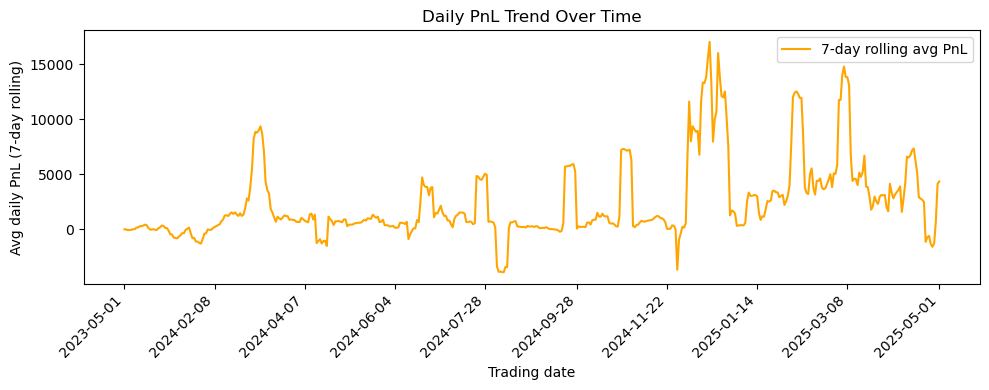

In [ ]:
import numpy as np
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(time_df["trade_date"], daily_pnl_7d, color="orange", label="7-day rolling avg PnL")

ax.set_xlabel("Trading date")
ax.set_ylabel("Avg daily PnL (7-day rolling)")
ax.set_title("Daily PnL Trend Over Time")
n_ticks = 10
idx = np.linspace(0, len(time_df)-1, n_ticks, dtype=int)
ax.set_xticks(time_df["trade_date"].iloc[idx])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend()
fig.tight_layout()
plt.show()

* The rolling PnL fluctuate on low level for almost entire 2023 to 2024 early, with several short frofit spikes in between, indicating that traders performance was relatively modest and unstable in that phase
* From late 2024 into early 2025 there is a clear regime of much higher rolling PnL, With multiple peakes above 10K-15K USD, suggested a period where market condition or trader behavior led to sustained strong profitability.

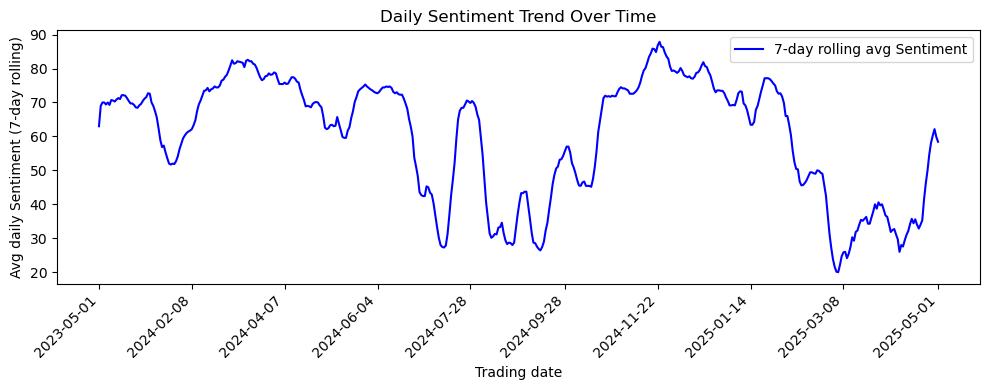

In [58]:
import numpy as np
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(time_df["trade_date"], daily_sent_7d, color="blue", label="7-day rolling avg Sentiment")

ax.set_xlabel("Trading date")
ax.set_ylabel("Avg daily Sentiment (7-day rolling)")
ax.set_title("Daily Sentiment Trend Over Time")
n_ticks = 10
idx = np.linspace(0, len(time_df)-1, n_ticks, dtype=int)
ax.set_xticks(time_df["trade_date"].iloc[idx])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend()
fig.tight_layout()
plt.show()

* The sentiment line oscillates between high values (Greed/Extreme Greed) and low values (Fear/Extreme Fear), often staying in one regime for several weeks at a time, which indicates clear sentiment “cycles” in the market.
* Comparing with the PnL trend, the strongest and most persistent high‑PnL period in early 2025 appears to coincide with a prolonged Greed/Extreme Greed regime, while some deep Fear phases line up with weaker or more volatile PnL, suggesting that trader performance is partly shaped by the prevailing sentiment environment.

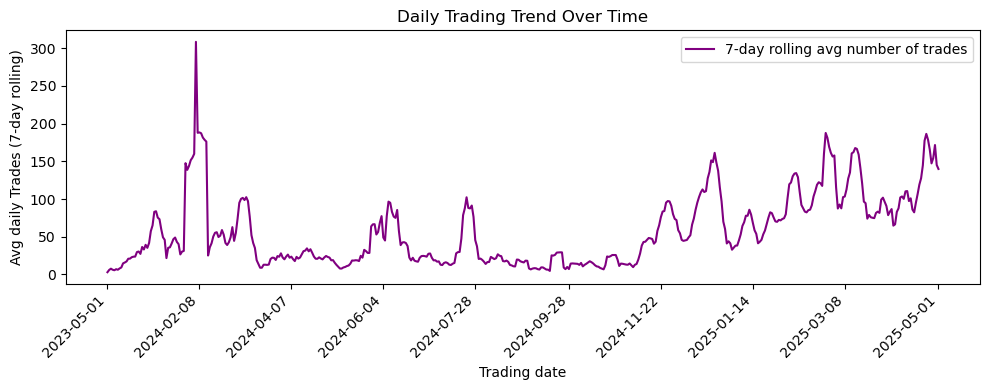

In [61]:
import numpy as np
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(time_df["trade_date"], daily_no_trades_7d, color="purple", label="7-day rolling avg number of trades")

ax.set_xlabel("Trading date")
ax.set_ylabel("Avg daily Trades (7-day rolling)")
ax.set_title("Daily Trading Trend Over Time")
n_ticks = 10
idx = np.linspace(0, len(time_df)-1, n_ticks, dtype=int)
ax.set_xticks(time_df["trade_date"].iloc[idx])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend()
fig.tight_layout()
plt.show()

* Trading activity is relatively low and sporadic through much of 2023 and mid‑2024, with a few short spikes, including one very sharp burst of activity around early 2024 where the 7‑day average briefly exceeds 300 trades per day.
* From late 2024 into early 2025 the rolling average number of trades steadily trends higher, with repeated peaks above 100–150 trades per day, which lines up with the period where average PnL was also elevated, indicating that traders both traded more frequently and earned higher profits during that regime.
